# Part 2: Automated Policy Design

## 2.1 Definition of Sustainable Development

Sustainable development is defined as long-term stability of population, natural resources, pollution, and quality of life — without system collapse.

We evaluate a scenario by its state at **year 2100** using four criteria, with quantitative requirements for each indicator:

| Dimension | Indicator | Quantitative Requirement |
|-----------|-----------|--------------------------|
| **Population** (P / POP) | $P_{min}$ — minimum population | $P_{min} > \text{threshold} = 1 \times 10^9$ (no collapse) |
|  | $P_{final}$ — population at 2100 |  |
|  | $\sigma_P$ — std. deviation of population | $\sigma_P / \bar{P} < 0.15$ (low oscillation) |
| **Natural Resources** (NR / NRFR) | $NR_{final}$ — fraction remaining at 2100 | $NR_{final} / NR_0 > 0.2$ (≥ 20% reserve) |
| **Pollution** (POL / PPOLX) | $POL_{max}$ — peak pollution index | $POL_{max} < 10$ (World2 POLR) or $< 10$ (World3 PPOLX) |
|  | $POL_{final}$ — pollution at 2100 | $POL_{final} < 0.5 \cdot POL_{max}$ (declining trend) |
| **Quality of Life** (QL / IOPC) | $QL_{final}$ — value at 2100 | $QL_{final} > 1.0$ (World2) or $IOPC > 400$ (World3) |
|  | $QL_{min}$ — minimum over 2000–2100 | $QL_{min} > 0.5$ of the standard value |

---

### Sustainability Score

Each indicator is normalized to $[0,1]$ using one of three strategies:

**(1) Higher-is-better, with a target reference value** (for $P$, $QL$):

$$
\hat{X} = \min\!\left(\frac{X}{X_{\text{ref}}},\, 1\right)
$$

References: $P_{\text{ref}} = 1 \times 10^9$ people; $QL_{\text{ref}} = 1.0$ (World2) or $IOPC_{\text{ref}} = 400 (World3).

**(2) Already in $[0,1]$** (for $NR$):

$$
\hat{NR}_{final} = \frac{NR_{final}}{NR_0}
$$

**(3) Lower-is-better, with a cap** (for $POL$, $\sigma_P$):

$$
\hat{X} = \min\!\left(\frac{X}{X_{\text{cap}}},\, 1\right)
$$

Caps: $POL_{\text{cap}} = 5$ (World2 POLR) or $10$ (World3 PPOLX); $\sigma_P^{\text{cap}} = 0.15 \cdot \bar{P}$.

Then combined into:

$$
S = w_P \, S_P + w_{NR} \, S_{NR} + w_{POL} \, S_{POL} + w_{QL} \, S_{QL}
$$

**Component scores:**

- Population stability:
$$
S_P = \alpha_1 \hat{P}_{final} + \alpha_2 \hat{P}_{\min} - \alpha_3 \hat{\sigma}_P
$$

- Resource preservation:
$$
S_{NR} = \hat{NR}_{final}
$$

- Pollution control:
$$
S_{POL} = \beta_1 (1 - \hat{POL}_{\max}) + \beta_2 (1 - \hat{POL}_{final})
$$

- Quality of life:
$$
S_{QL} = \gamma_1 \hat{QL}_{final} + \gamma_2 \hat{QL}_{\min}
$$

Higher $S$ = more sustainable. Scenarios violating any quantitative requirement above are considered **infeasible** and excluded.


## 2.2 Automated policy search
### Step 0: Setup and Imports

In [1]:
import sys
sys.path.insert(0, '../pyworld2-main')
sys.path.insert(0, '../pyworld3-main')

import numpy as np
import matplotlib.pyplot as plt
import json
import os
from itertools import product

from pyworld2 import World2
from pyworld3 import World3

print('Both models imported successfully.')

Both models imported successfully.


### Step 1: World2 — Quick Prototype

#### 1.a: Define Sustainability Score for World2

In [2]:
# === Sustainability evaluation per Section 2.1 ===
EVAL_WINDOW       = (2000, 2100)
P_REF             = 8.0e9
P_MIN_THR         = 1.0e9
SIGMA_RATIO_THR   = 0.15
NR_RATIO_THR      = 0.20
POL_DECLINE_RATIO = 0.5

# World2-specific
W2_QL_REF         = 1.0
W2_QL_FINAL_THR   = 0.8
W2_QL_MIN_THR     = 0.5
W2_POL_CAP        = 5.0   # POLR
W2_POL_MAX_THR    = 5.0

# Sub-weights (alpha for P; beta for POL; gamma for QL) and dimension weights
ALPHA   = (0.5, 0.4, 0.1)
BETA    = (0.5, 0.5)
GAMMA   = (0.5, 0.5)
W_DIM   = (0.25, 0.25, 0.25, 0.25)


def _clip01(x):
    return float(np.clip(x, 0.0, 1.0))


def w2_sustainability_score(model, verbose=False):
    """Sustainability score for World2 (Section 2.1).

    Returns a dict with the combined score `total`, a `feasible` flag,
    list of `violations`, component scores S_P/S_NR/S_POL/S_QL, and the
    raw indicators.
    """
    t = model.time
    mask = (t >= EVAL_WINDOW[0]) & (t <= EVAL_WINDOW[1])
    P, POL, QL = model.p[mask], model.polr[mask], model.ql[mask]

    P_final  = float(P[-1])
    P_min    = float(np.nanmin(P))
    P_mean   = float(np.nanmean(P))
    sigma_P  = float(np.nanstd(P))
    NR_ratio = float(model.nr[-1] / model.nr[0]) if model.nr[0] else 0.0
    POL_max  = float(np.nanmax(POL))
    POL_final = float(POL[-1])
    QL_final = float(QL[-1])
    QL_min   = float(np.nanmin(QL))

    # Feasibility check
    violations = []
    if P_min < P_MIN_THR:                                violations.append('P_min')
    if P_mean and sigma_P / P_mean > SIGMA_RATIO_THR:    violations.append('sigma_P')
    if NR_ratio < NR_RATIO_THR:                          violations.append('NR_final')
    if POL_max > W2_POL_MAX_THR:                         violations.append('POL_max')
    if POL_max > 0 and POL_final > POL_DECLINE_RATIO * POL_max: violations.append('POL_decline')
    if QL_final < W2_QL_FINAL_THR:                       violations.append('QL_final')
    if QL_min   < W2_QL_MIN_THR:                         violations.append('QL_min')
    feasible = (len(violations) == 0)

    # Normalize
    P_hat_final = min(P_final / P_REF, 1.0)
    P_hat_min   = min(P_min   / P_REF, 1.0)
    sigma_hat   = min(sigma_P / (SIGMA_RATIO_THR * P_mean), 1.0) if P_mean else 1.0
    NR_hat      = _clip01(NR_ratio)
    POL_hat_max = min(POL_max   / W2_POL_CAP, 1.0)
    POL_hat_fin = min(POL_final / W2_POL_CAP, 1.0)
    QL_hat_final = min(QL_final / W2_QL_REF, 1.0)
    QL_hat_min   = min(QL_min   / W2_QL_REF, 1.0)

    # Component scores
    S_P   = _clip01(ALPHA[0]*P_hat_final + ALPHA[1]*P_hat_min - ALPHA[2]*sigma_hat)
    S_NR  = NR_hat
    S_POL = _clip01(BETA[0]*(1 - POL_hat_max) + BETA[1]*(1 - POL_hat_fin))
    S_QL  = _clip01(GAMMA[0]*QL_hat_final + GAMMA[1]*QL_hat_min)

    total = (W_DIM[0]*S_P + W_DIM[1]*S_NR + W_DIM[2]*S_POL + W_DIM[3]*S_QL)

    out = {
        'total': total,
        'feasible': feasible,
        'violations': violations,
        'S_P': S_P, 'S_NR': S_NR, 'S_POL': S_POL, 'S_QL': S_QL,
        'P_final': P_final, 'P_min': P_min,
        'sigma_ratio': sigma_P / P_mean if P_mean else float('nan'),
        'NR_ratio': NR_ratio,
        'POL_max': POL_max, 'POL_final': POL_final,
        'QL_final': QL_final, 'QL_min': QL_min,
        # Back-compat aliases used by downstream cells
        'pop_score': S_P, 'nr_score': S_NR, 'pol_score': S_POL, 'ql_score': S_QL,
        'nr_remaining_pct': NR_ratio * 100,
        'peak_polr': POL_max,
        'peak_pop': float(np.nanmax(P)), 'final_pop': P_final,
    }
    if verbose:
        print(f"  total={total:.4f}  feasible={feasible}  violations={violations}")
        print(f"  S_P={S_P:.3f}  S_NR={S_NR:.3f}  S_POL={S_POL:.3f}  S_QL={S_QL:.3f}")
    return out


# Baseline (BAU)
w2_std = World2()
w2_std.set_state_variables(); w2_std.set_initial_state()
w2_std.set_table_functions(); w2_std.set_switch_functions()
w2_std.run()
baseline_score = w2_sustainability_score(w2_std, verbose=True)
print('\n=== World2 BAU raw indicators ===')
for k in ['P_final','P_min','sigma_ratio','NR_ratio','POL_max','POL_final','QL_final','QL_min']:
    print(f"  {k:>12}: {baseline_score[k]:.4f}")


  total=0.3609  feasible=False  violations=['POL_max', 'QL_final']
  S_P=0.345  S_NR=0.309  S_POL=0.240  S_QL=0.550

=== World2 BAU raw indicators ===
       P_final: 3704384762.9151
         P_min: 3704384762.9151
   sigma_ratio: 0.1082
      NR_ratio: 0.3092
       POL_max: 5.7130
     POL_final: 2.5993
      QL_final: 0.5498
        QL_min: 0.5498


#### 1.b: World2 Grid Search — Single Parameters

In [3]:
def run_w2_policy(param_changes, trigger_year=1970):
    """
    Run World2 with given parameter changes applied at trigger_year.
    param_changes: dict like {'BRN': 0.02, 'POLN': 0.5}
    """
    defaults = {
        'BRN':  {'val': 0.04,  'trigger': 'SWT1'},
        'NRUN': {'val': 1.0,   'trigger': 'SWT2'},
        'DRN':  {'val': 0.028, 'trigger': 'SWT3'},
        'FC':   {'val': 1.0,   'trigger': 'SWT7'},
        'CIGN': {'val': 0.05,  'trigger': 'SWT4'},
        'CIDN': {'val': 0.025, 'trigger': 'SWT5'},
        'POLN': {'val': 1.0,   'trigger': 'SWT6'},
    }
    switch_list = []
    for name, info in defaults.items():
        entry = {
            name: info['val'],
            f"{name}1": param_changes.get(name, info['val']),
            "trigger.name": info['trigger'],
            "trigger.value": trigger_year
        }
        switch_list.append(entry)
    
    filepath = 'temp_w2_search.json'
    with open(filepath, 'w') as f:
        json.dump(switch_list, f, indent=1)
    
    model = World2()
    model.set_state_variables()
    model.set_initial_state()
    model.set_table_functions()
    model.set_switch_functions(filepath)
    model.run()
    return model

# Grid search over key parameters
param_grid = {
    'BRN':  [0.02, 0.025, 0.03, 0.035, 0.04],
    'POLN': [0.25, 0.5, 0.75, 1.0],
    'NRUN': [0.25, 0.5, 0.75, 1.0],
    'CIGN': [0.02, 0.035, 0.05],
}

# Run all single-parameter variations
w2_results = []
for param_name, values in param_grid.items():
    for val in values:
        model = run_w2_policy({param_name: val})
        score = w2_sustainability_score(model)
        score['param'] = param_name
        score['value'] = val
        score['policy'] = {param_name: val}
        w2_results.append(score)

# Sort by total score
w2_results.sort(key=lambda x: x['total'], reverse=True)

print(f'{"Param":<8} {"Value":<8} {"Total":>8} {"Pop":>8} {"NR%":>8} {"Pol":>8} {"QL":>8}')
print('-' * 60)
for r in w2_results[:15]:
    print(f"{r['param']:<8} {r['value']:<8.3f} {r['total']:>8.4f} {r['pop_score']:>8.4f} {r['nr_remaining_pct']:>7.1f}% {r['pol_score']:>8.4f} {r['ql_score']:>8.4f}")

Param    Value       Total      Pop      NR%      Pol       QL
------------------------------------------------------------
CIGN     0.020      0.5772   0.2010    58.4%   0.9119   0.6114
CIGN     0.035      0.5437   0.3251    44.0%   0.8045   0.6050
POLN     0.250      0.5280   0.3972    31.0%   0.9036   0.5011
POLN     0.500      0.4938   0.3868    31.0%   0.7678   0.5107
POLN     0.750      0.4409   0.3715    30.9%   0.5577   0.5249
BRN      0.020      0.4108   0.2513    29.9%   0.1658   0.9267
BRN      0.025      0.3883   0.2859    30.2%   0.2051   0.7605
BRN      0.030      0.3756   0.3013    30.4%   0.2184   0.6789
BRN      0.035      0.3663   0.3173    30.6%   0.2288   0.6133
BRN      0.040      0.3609   0.3446    30.9%   0.2401   0.5498
POLN     1.000      0.3609   0.3446    30.9%   0.2401   0.5498
NRUN     1.000      0.3609   0.3446    30.9%   0.2401   0.5498
CIGN     0.050      0.3609   0.3446    30.9%   0.2401   0.5498
NRUN     0.750      0.3503   0.3739    35.6%   0.0000   0

#### 1.c: World2 Combinatorial Search — Multi-Parameter Policies

In [4]:
# Combinatorial search: vary BRN, POLN, NRUN together
brn_vals  = [0.02, 0.025, 0.03, 0.035, 0.04]
poln_vals = [0.25, 0.5, 0.75, 1.0]
nrun_vals = [0.25, 0.5, 0.75, 1.0]

w2_combo_results = []
total_combos = len(brn_vals) * len(poln_vals) * len(nrun_vals)
print(f'Running {total_combos} combined policy scenarios...')

for brn, poln, nrun in product(brn_vals, poln_vals, nrun_vals):
    policy = {'BRN': brn, 'POLN': poln, 'NRUN': nrun}
    model = run_w2_policy(policy)
    score = w2_sustainability_score(model)
    score['policy'] = policy
    w2_combo_results.append(score)

w2_combo_results.sort(key=lambda x: x['total'], reverse=True)

print(f'\nTop 10 combined policies (World2):')
print(f'{"BRN":<7} {"POLN":<7} {"NRUN":<7} {"Total":>8} {"Pop":>8} {"NR%":>8} {"Pol":>8} {"QL":>8}')
print('-' * 70)
for r in w2_combo_results[:10]:
    p = r['policy']
    print(f"{p['BRN']:<7.3f} {p['POLN']:<7.2f} {p['NRUN']:<7.2f} {r['total']:>8.4f} {r['pop_score']:>8.4f} {r['nr_remaining_pct']:>7.1f}% {r['pol_score']:>8.4f} {r['ql_score']:>8.4f}")

Running 80 combined policy scenarios...



Top 10 combined policies (World2):
BRN     POLN    NRUN       Total      Pop      NR%      Pol       QL
----------------------------------------------------------------------
0.025   0.25    0.25      0.6494   0.5377    57.6%   0.5484   0.9359
0.020   0.25    0.25      0.6352   0.4859    56.8%   0.4868   1.0000
0.020   0.25    0.50      0.6339   0.4503    41.8%   0.7611   0.9061
0.030   0.25    0.25      0.6323   0.5835    58.4%   0.6015   0.7607
0.040   0.25    0.25      0.6313   0.6623    59.8%   0.6749   0.5903
0.035   0.25    0.25      0.6281   0.6253    59.0%   0.6391   0.6580
0.025   0.25    0.50      0.6135   0.4937    42.3%   0.7793   0.7576
0.030   0.25    0.50      0.6056   0.5314    42.8%   0.7935   0.6697
0.020   0.25    0.75      0.6054   0.3940    34.1%   0.8487   0.8374
0.035   0.25    0.50      0.6021   0.5673    43.3%   0.8044   0.6037


#### 1.d: World2 — Visualize Best Policy vs Baseline

Best World2 policy: {'BRN': 0.025, 'POLN': 0.25, 'NRUN': 0.25}


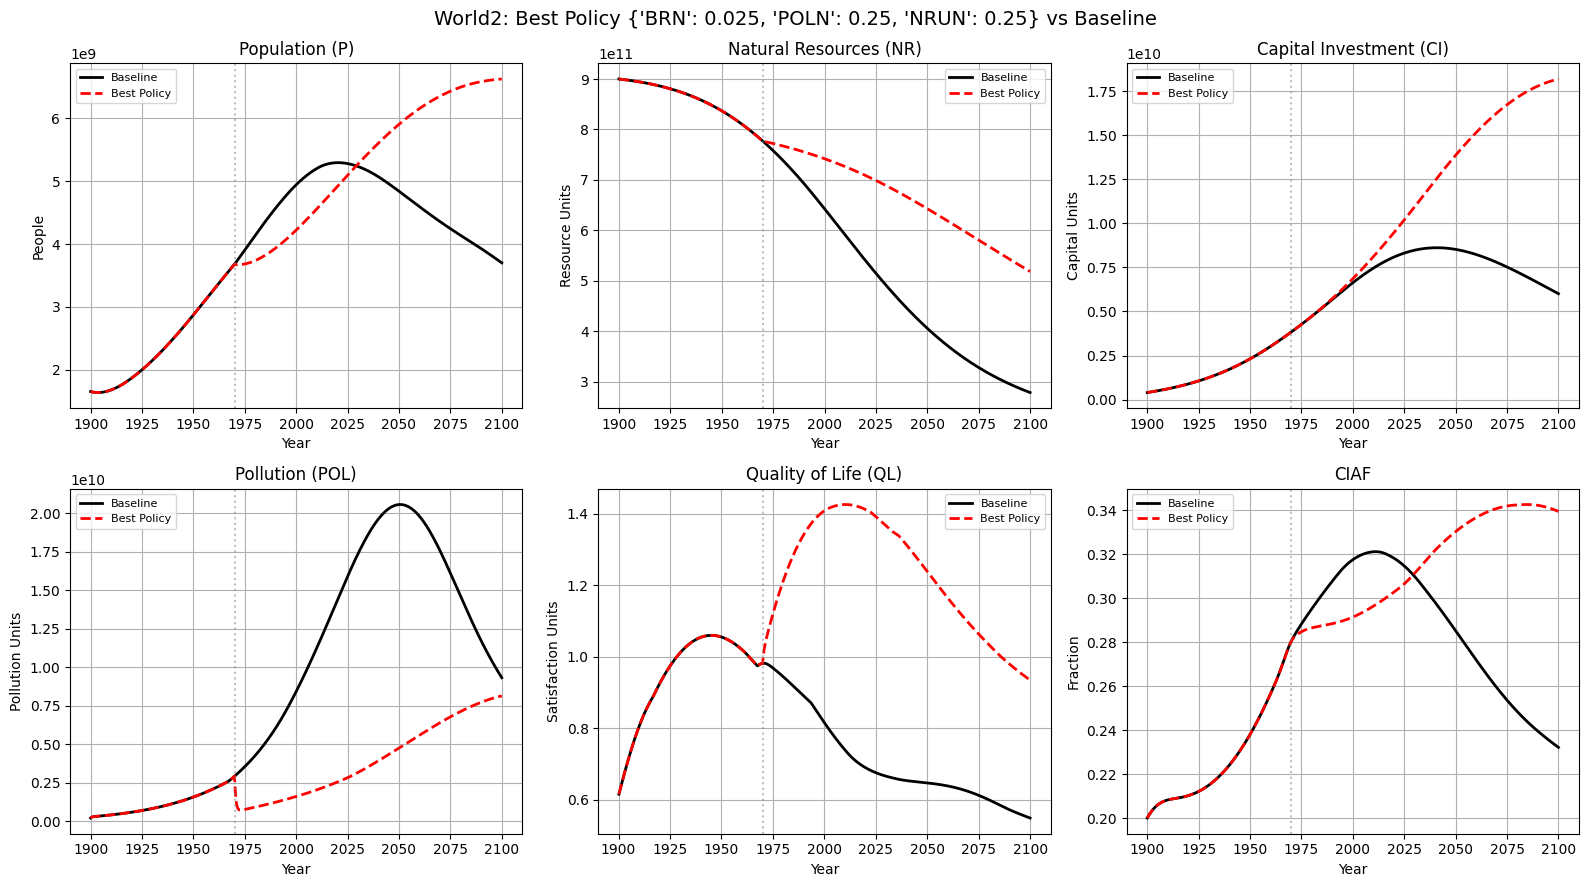

In [5]:
# Run the best World2 policy
best_w2_policy = w2_combo_results[0]['policy']
print(f'Best World2 policy: {best_w2_policy}')
w2_best = run_w2_policy(best_w2_policy)

# Compare with baseline
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'World2: Best Policy {best_w2_policy} vs Baseline', fontsize=14)

plot_vars = [
    ('p',    'Population (P)',         'People'),
    ('nr',   'Natural Resources (NR)', 'Resource Units'),
    ('ci',   'Capital Investment (CI)','Capital Units'),
    ('pol',  'Pollution (POL)',        'Pollution Units'),
    ('ql',   'Quality of Life (QL)',   'Satisfaction Units'),
    ('ciaf', 'CIAF',                   'Fraction'),
]

for idx, (attr, title, ylabel) in enumerate(plot_vars):
    ax = axes[idx // 3, idx % 3]
    ax.plot(w2_std.time, getattr(w2_std, attr), 'k-', linewidth=2, label='Baseline')
    ax.plot(w2_best.time, getattr(w2_best, attr), 'r--', linewidth=2, label='Best Policy')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.axvline(x=1970, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


### Step 2: World3 — Automated Policy Search

Now we apply the same strategy to the more complex World3 model. The key policy levers are:
- `nruf2`: resource usage factor (after pyear)
- `ppgf2`: pollution generation factor (after pyear)
- `fioac2`: fraction of industrial output to agriculture (after pyear)
- `lyf2`: land yield factor (after pyear)
- `dcfsn`: desired completed family size normal
- `fcest`: fertility control effectiveness set time
- `zpgt`: zero population growth time
- `pyear`: policy implementation year

#### 2.a: Define Sustainability Score for World3

In [6]:
# === World3-specific evaluation parameters (Section 2.1) ===
W3_IOPC_REF       = 400.0
W3_IOPC_FINAL_THR = 300.0
W3_IOPC_MIN_THR   = 150.0
W3_POL_CAP        = 10.0  # PPOLX
W3_POL_MAX_THR    = 10.0


def run_w3(pyear=1975, **kwargs):
    """Run World3 with given constant overrides at pyear."""
    w3 = World3(year_max=2100, dt=0.5, pyear=pyear)
    w3.init_world3_constants(**kwargs)
    w3.init_world3_variables()
    w3.set_world3_table_functions()
    w3.set_world3_delay_functions()
    w3.run_world3(fast=True)
    return w3


def w3_sustainability_score(model, verbose=False):
    """Sustainability score for World3 (Section 2.1)."""
    t = model.time
    mask = (t >= EVAL_WINDOW[0]) & (t <= EVAL_WINDOW[1])
    P, POL, IOPC = model.pop[mask], model.ppolx[mask], model.iopc[mask]
    NRFR_final = float(model.nrfr[-1])

    P_final  = float(P[-1])
    P_min    = float(np.nanmin(P))
    P_mean   = float(np.nanmean(P))
    sigma_P  = float(np.nanstd(P))
    POL_max  = float(np.nanmax(POL))
    POL_final = float(POL[-1])
    IOPC_final = float(IOPC[-1])
    IOPC_min   = float(np.nanmin(IOPC))

    violations = []
    if P_min < P_MIN_THR:                                violations.append('P_min')
    if P_mean and sigma_P / P_mean > SIGMA_RATIO_THR:    violations.append('sigma_P')
    if NRFR_final < NR_RATIO_THR:                        violations.append('NR_final')
    if POL_max > W3_POL_MAX_THR:                         violations.append('POL_max')
    if POL_max > 0 and POL_final > POL_DECLINE_RATIO * POL_max: violations.append('POL_decline')
    if IOPC_final < W3_IOPC_FINAL_THR:                   violations.append('IOPC_final')
    if IOPC_min   < W3_IOPC_MIN_THR:                     violations.append('IOPC_min')
    feasible = (len(violations) == 0)

    P_hat_final  = min(P_final / P_REF, 1.0)
    P_hat_min    = min(P_min   / P_REF, 1.0)
    sigma_hat    = min(sigma_P / (SIGMA_RATIO_THR * P_mean), 1.0) if P_mean else 1.0
    NR_hat       = _clip01(NRFR_final)
    POL_hat_max  = min(POL_max   / W3_POL_CAP, 1.0)
    POL_hat_fin  = min(POL_final / W3_POL_CAP, 1.0)
    QL_hat_final = min(IOPC_final / W3_IOPC_REF, 1.0)
    QL_hat_min   = min(IOPC_min   / W3_IOPC_REF, 1.0)

    S_P   = _clip01(ALPHA[0]*P_hat_final + ALPHA[1]*P_hat_min - ALPHA[2]*sigma_hat)
    S_NR  = NR_hat
    S_POL = _clip01(BETA[0]*(1 - POL_hat_max) + BETA[1]*(1 - POL_hat_fin))
    S_QL  = _clip01(GAMMA[0]*QL_hat_final + GAMMA[1]*QL_hat_min)

    total = (W_DIM[0]*S_P + W_DIM[1]*S_NR + W_DIM[2]*S_POL + W_DIM[3]*S_QL)

    out = {
        'total': total,
        'feasible': feasible,
        'violations': violations,
        'S_P': S_P, 'S_NR': S_NR, 'S_POL': S_POL, 'S_QL': S_QL,
        'P_final': P_final, 'P_min': P_min,
        'sigma_ratio': sigma_P / P_mean if P_mean else float('nan'),
        'NR_ratio': NRFR_final,
        'POL_max': POL_max, 'POL_final': POL_final,
        'IOPC_final': IOPC_final, 'IOPC_min': IOPC_min,
        # Back-compat aliases used by downstream cells
        'pop_score': S_P, 'nr_score': S_NR, 'pol_score': S_POL,
        'iopc_score': S_QL, 'fpc_score': S_QL,
        'peak_pop': float(np.nanmax(P)), 'final_pop': P_final,
        'peak_ppolx': POL_max,
        'fpc_mean': float(np.nanmean(model.fpc[mask])),
        'iopc_mean': float(np.nanmean(IOPC)),
    }
    if verbose:
        print(f"  total={total:.4f}  feasible={feasible}  violations={violations}")
        print(f"  S_P={S_P:.3f}  S_NR={S_NR:.3f}  S_POL={S_POL:.3f}  S_QL={S_QL:.3f}")
    return out


# Baseline
w3_std = run_w3()
baseline_w3 = w3_sustainability_score(w3_std, verbose=True)
print('\n=== World3 BAU raw indicators ===')
for k in ['P_final','P_min','sigma_ratio','NR_ratio','POL_max','POL_final','IOPC_final','IOPC_min']:
    print(f"  {k:>12}: {baseline_w3[k]:.4f}")


  total=0.2490  feasible=False  violations=['sigma_P', 'NR_final', 'POL_max', 'IOPC_final', 'IOPC_min']
  S_P=0.347  S_NR=0.152  S_POL=0.470  S_QL=0.027

=== World3 BAU raw indicators ===
       P_final: 3976857676.1480
         P_min: 3976857676.1480
   sigma_ratio: 0.1742
      NR_ratio: 0.1520
       POL_max: 11.0018
     POL_final: 0.6019
    IOPC_final: 10.7107
      IOPC_min: 10.7107


#### 2.b: World3 Grid Search — Explore Policy Space

In [7]:
# Define realistic parameter ranges for World3
# _2 values are applied after pyear; _1 stays at default

w3_param_grid = {
    'nruf2':  [0.25, 0.5, 0.75, 1.0],        # resource usage factor
    'ppgf2':  [0.25, 0.5, 0.75, 1.0],        # pollution generation factor
    'fioac2': [0.3, 0.43, 0.5, 0.6],         # fraction to agriculture
    'lyf2':   [1.0, 1.5, 2.0],               # land yield factor (tech improvement)
    'dcfsn':  [2.0, 2.5, 3.0, 4.0],          # desired family size
}

# Single parameter sweep first
w3_single_results = []
for param_name, values in w3_param_grid.items():
    for val in values:
        try:
            model = run_w3(**{param_name: val})
            score = w3_sustainability_score(model)
            score['param'] = param_name
            score['value'] = val
            w3_single_results.append(score)
        except Exception as e:
            print(f'  Error with {param_name}={val}: {e}')

w3_single_results.sort(key=lambda x: x['total'], reverse=True)

print(f'{"Param":<10} {"Value":<8} {"Total":>8} {"Pop":>8} {"NR":>8} {"Pol":>8} {"FPC":>8} {"IOPC":>8}')
print('-' * 72)
for r in w3_single_results[:15]:
    print(f"{r['param']:<10} {r['value']:<8.2f} {r['total']:>8.4f} {r['pop_score']:>8.4f} {r['nr_score']:>8.4f} {r['pol_score']:>8.4f} {r['fpc_score']:>8.4f} {r['iopc_score']:>8.4f}")

Param      Value       Total      Pop       NR      Pol      FPC     IOPC
------------------------------------------------------------------------
fioac2     0.60       0.5175   0.5409   0.5908   0.8235   0.1149   0.1149
nruf2      0.25       0.3655   0.2716   0.3234   0.0000   0.8671   0.8671
ppgf2      0.25       0.3542   0.3611   0.1421   0.8896   0.0239   0.0239
fioac2     0.50       0.3456   0.4965   0.2223   0.5777   0.0858   0.0858
ppgf2      0.50       0.3220   0.3583   0.1446   0.7607   0.0247   0.0247
ppgf2      0.75       0.2835   0.3541   0.1477   0.6066   0.0256   0.0256
nruf2      0.75       0.2691   0.4131   0.1700   0.4386   0.0548   0.0548
nruf2      0.50       0.2607   0.3784   0.2116   0.3091   0.1437   0.1437
nruf2      1.00       0.2490   0.3474   0.1520   0.4699   0.0268   0.0268
ppgf2      1.00       0.2490   0.3474   0.1520   0.4699   0.0268   0.0268
fioac2     0.43       0.2490   0.3474   0.1520   0.4699   0.0268   0.0268
lyf2       1.00       0.2490   0.3474  

#### 2.c: World3 Combinatorial Search — Multi-Parameter Policies

In [8]:
# Combinatorial search over the most impactful parameters
nruf2_vals  = [0.5, 0.75, 1.0]
ppgf2_vals  = [0.25, 0.5, 0.75]
dcfsn_vals  = [2.0, 2.5, 3.0]
fioac2_vals = [0.43, 0.5]
lyf2_vals   = [1.0, 1.5, 2.0]
pyear_vals  = [1980, 1990, 2000]

total_combos = (len(nruf2_vals) * len(ppgf2_vals) * len(dcfsn_vals) * 
                len(fioac2_vals) * len(lyf2_vals) * len(pyear_vals))
print(f'Running {total_combos} World3 policy scenarios...')

w3_combo_results = []
count = 0

for nruf2, ppgf2, dcfsn, fioac2, lyf2, pyear in product(
    nruf2_vals, ppgf2_vals, dcfsn_vals, fioac2_vals, lyf2_vals, pyear_vals):
    
    policy = {
        'nruf2': nruf2, 'ppgf2': ppgf2, 'dcfsn': dcfsn,
        'fioac2': fioac2, 'lyf2': lyf2
    }
    try:
        model = run_w3(pyear=pyear, **policy)
        score = w3_sustainability_score(model)
        score['policy'] = policy.copy()
        score['pyear'] = pyear
        w3_combo_results.append(score)
    except Exception as e:
        pass  # skip failed runs
    
    count += 1
    if count % 100 == 0:
        print(f'  Completed {count}/{total_combos} runs...')

w3_combo_results.sort(key=lambda x: x['total'], reverse=True)
print(f'\nCompleted {len(w3_combo_results)} successful runs.')

print(f'\nTop 10 World3 combined policies:')
print(f'{"pyear":>6} {"nruf2":>6} {"ppgf2":>6} {"dcfsn":>6} {"fioac2":>7} {"lyf2":>5} {"Total":>8} {"Pop":>8} {"NR":>8} {"Pol":>8} {"FPC":>8} {"IOPC":>8}')
print('-' * 95)
for r in w3_combo_results[:10]:
    p = r['policy']
    print(f"{r['pyear']:>6} {p['nruf2']:>6.2f} {p['ppgf2']:>6.2f} {p['dcfsn']:>6.1f} {p['fioac2']:>7.2f} {p['lyf2']:>5.1f} {r['total']:>8.4f} {r['pop_score']:>8.4f} {r['nr_score']:>8.4f} {r['pol_score']:>8.4f} {r['fpc_score']:>8.4f} {r['iopc_score']:>8.4f}")

Running 486 World3 policy scenarios...


  Completed 100/486 runs...


  Completed 200/486 runs...


  Completed 300/486 runs...


  Completed 400/486 runs...



Completed 486 successful runs.

Top 10 World3 combined policies:
 pyear  nruf2  ppgf2  dcfsn  fioac2  lyf2    Total      Pop       NR      Pol      FPC     IOPC
-----------------------------------------------------------------------------------------------
  1980   0.50   0.25    2.0    0.43   2.0   0.3632   0.0000   0.2655   0.8506   0.3368   0.3368
  1980   0.50   0.25    2.0    0.50   2.0   0.3606   0.0000   0.2652   0.8504   0.3270   0.3270
  1980   0.50   0.25    3.0    0.50   1.0   0.3578   0.1691   0.1899   0.8652   0.2072   0.2072
  1980   0.50   0.25    2.0    0.43   1.5   0.3540   0.0000   0.2731   0.8489   0.2941   0.2941
  1980   0.50   0.25    2.0    0.50   1.5   0.3520   0.0000   0.2730   0.8485   0.2864   0.2864
  1980   0.50   0.25    2.0    0.50   1.0   0.3503   0.0000   0.2764   0.8425   0.2822   0.2822
  1980   0.50   0.50    2.0    0.43   2.0   0.3490   0.0000   0.2664   0.7964   0.3332   0.3332
  1980   0.50   0.25    2.0    0.43   1.0   0.3488   0.0000   0.2786  

#### 2.d: Visualize Best World3 Policy vs Baseline

Best World3 policy:
  pyear = 1980
  nruf2 = 0.5
  ppgf2 = 0.25
  dcfsn = 2.0
  fioac2 = 0.43
  lyf2 = 2.0
  Total score = 0.3632


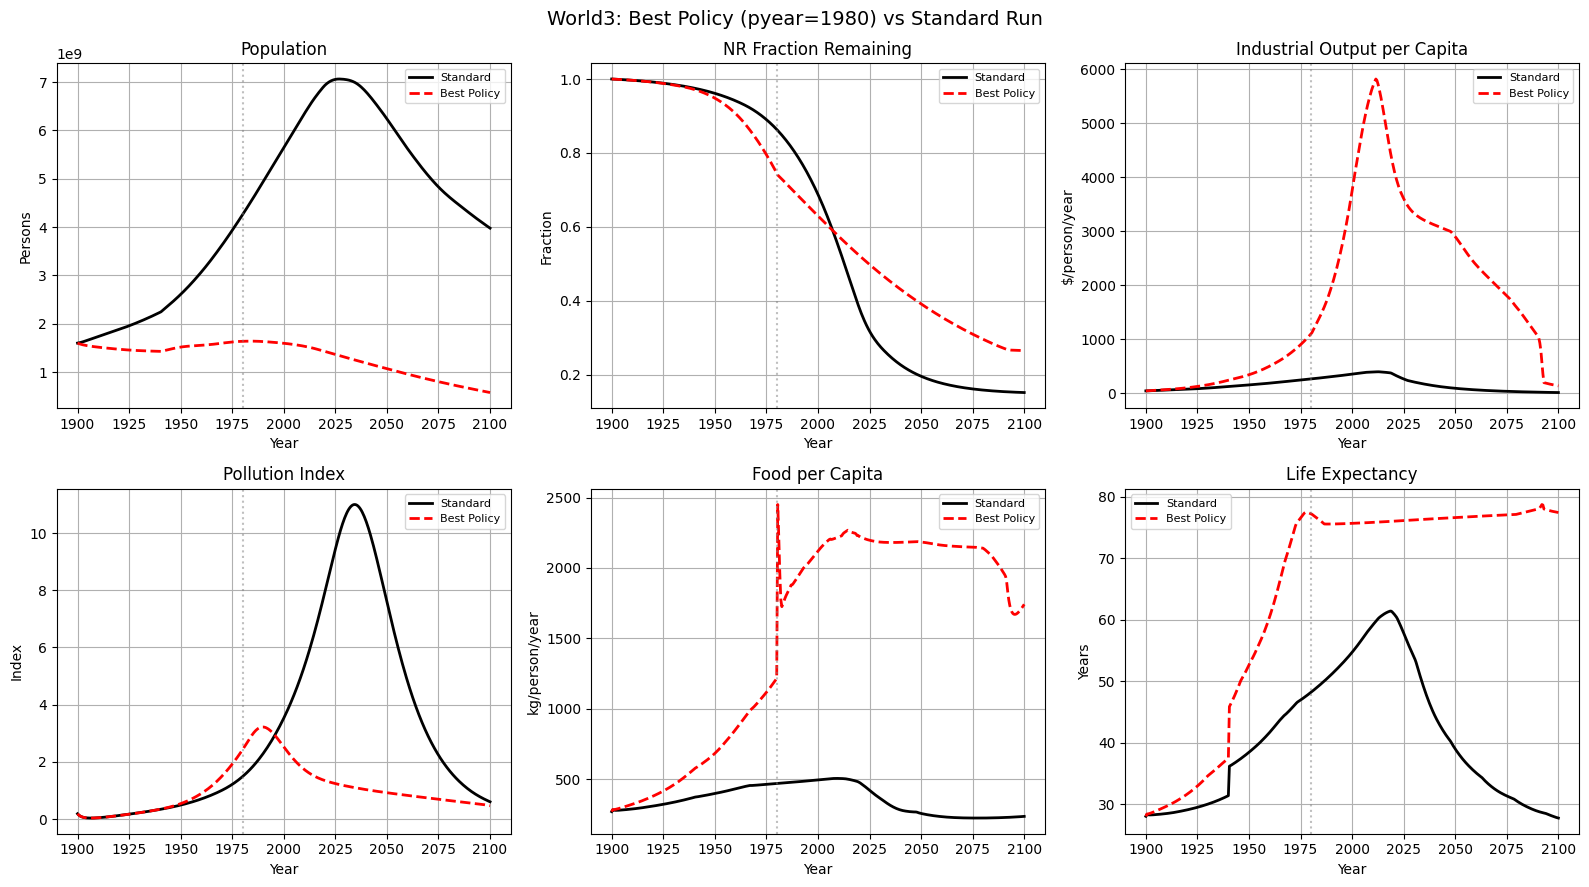

In [9]:
# Run the best World3 policy
best_result = w3_combo_results[0]
best_policy = best_result['policy']
best_pyear = best_result['pyear']

print(f'Best World3 policy:')
print(f'  pyear = {best_pyear}')
for k, v in best_policy.items():
    print(f'  {k} = {v}')
print(f'  Total score = {best_result["total"]:.4f}')

w3_best = run_w3(pyear=best_pyear, **best_policy)

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'World3: Best Policy (pyear={best_pyear}) vs Standard Run', fontsize=14)

w3_plot_vars = [
    ('pop',   'Population',                  'Persons'),
    ('nrfr',  'NR Fraction Remaining',       'Fraction'),
    ('iopc',  'Industrial Output per Capita', '$/person/year'),
    ('ppolx', 'Pollution Index',              'Index'),
    ('fpc',   'Food per Capita',              'kg/person/year'),
    ('le',    'Life Expectancy',              'Years'),
]

for idx, (attr, title, ylabel) in enumerate(w3_plot_vars):
    ax = axes[idx // 3, idx % 3]
    ax.plot(w3_std.time, getattr(w3_std, attr), 'k-', linewidth=2, label='Standard')
    ax.plot(w3_best.time, getattr(w3_best, attr), 'r--', linewidth=2, label='Best Policy')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.axvline(x=best_pyear, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2.e: Sensitivity Analysis — Which Parameters Matter Most?

In [10]:
# Analyze which parameters have the most influence on total score
import pandas as pd

# Build a DataFrame from combo results
rows = []
for r in w3_combo_results:
    row = r['policy'].copy()
    row['pyear'] = r['pyear']
    row['total'] = r['total']
    rows.append(row)

df = pd.DataFrame(rows)

# Mean score by each parameter value
print('=== Mean Sustainability Score by Parameter Value ===')
for col in ['nruf2', 'ppgf2', 'dcfsn', 'fioac2', 'lyf2', 'pyear']:
    print(f'\n{col}:')
    grouped = df.groupby(col)['total'].mean().sort_values(ascending=False)
    for val, mean_score in grouped.items():
        print(f'  {val:>8} -> mean score: {mean_score:.4f}')

=== Mean Sustainability Score by Parameter Value ===

nruf2:
       0.5 -> mean score: 0.2496
      0.75 -> mean score: 0.2278
       1.0 -> mean score: 0.2235

ppgf2:
      0.25 -> mean score: 0.2468
       0.5 -> mean score: 0.2366
      0.75 -> mean score: 0.2176

dcfsn:
       2.0 -> mean score: 0.2487
       3.0 -> mean score: 0.2393
       2.5 -> mean score: 0.2130

fioac2:
       0.5 -> mean score: 0.2399
      0.43 -> mean score: 0.2274

lyf2:
       2.0 -> mean score: 0.2344
       1.0 -> mean score: 0.2334
       1.5 -> mean score: 0.2331

pyear:
      1980 -> mean score: 0.2528
      1990 -> mean score: 0.2343
      2000 -> mean score: 0.2138


#### 2.f: Compare Top 3 Policies Side by Side

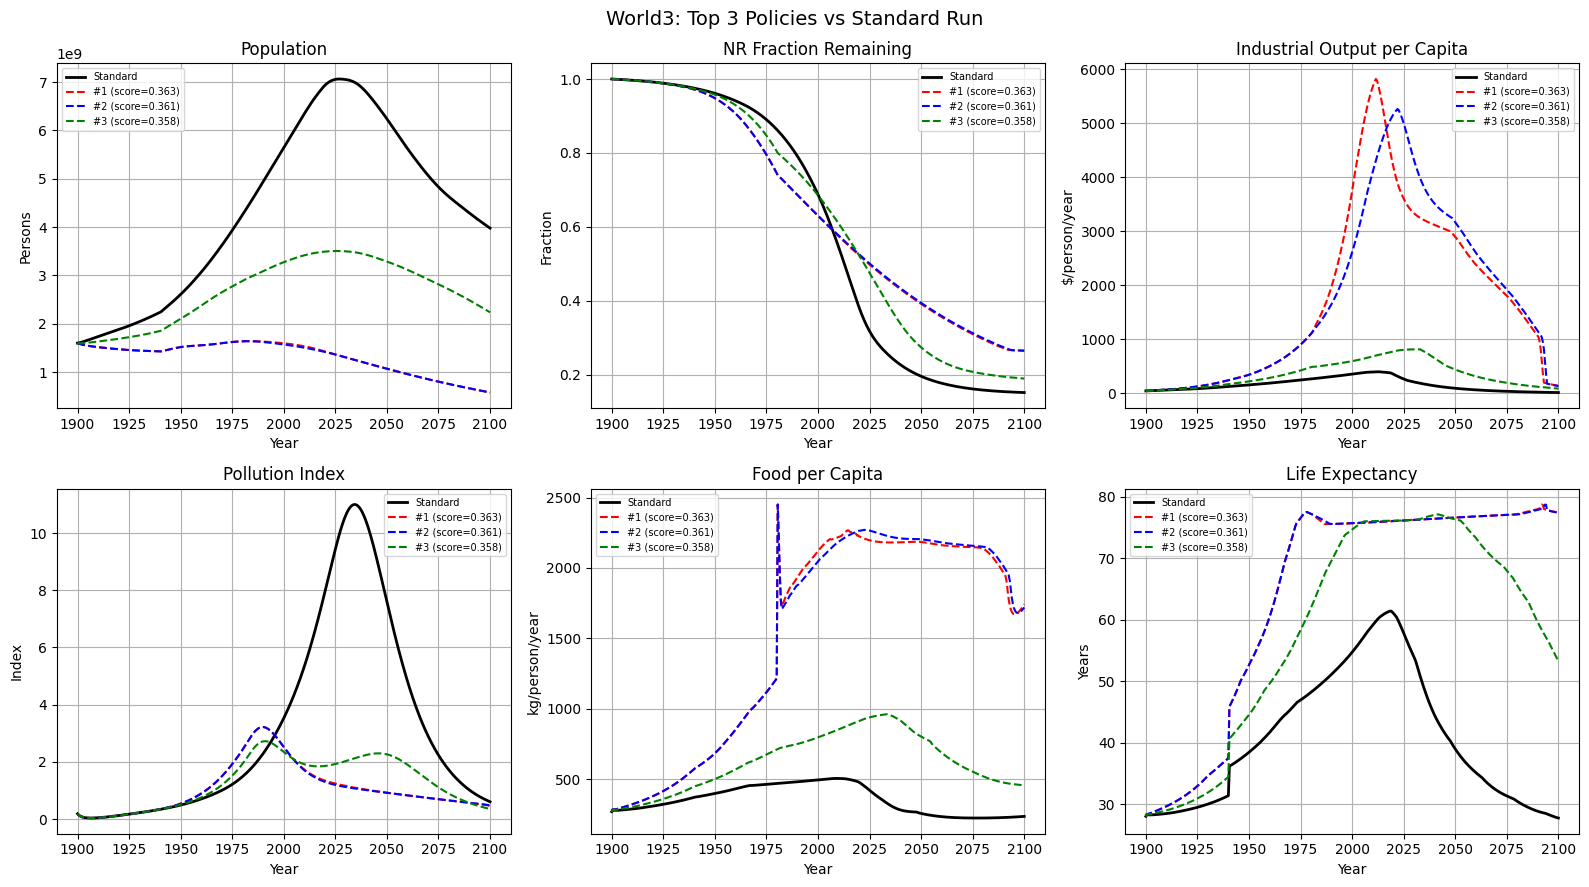

In [11]:
# Run top 3 policies and plot together
top3_models = []
top3_labels = []
for i, r in enumerate(w3_combo_results[:3]):
    p = r['policy']
    m = run_w3(pyear=r['pyear'], **p)
    top3_models.append(m)
    top3_labels.append(f"#{i+1} (score={r['total']:.3f})")

colors = ['red', 'blue', 'green']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('World3: Top 3 Policies vs Standard Run', fontsize=14)

for idx, (attr, title, ylabel) in enumerate(w3_plot_vars):
    ax = axes[idx // 3, idx % 3]
    ax.plot(w3_std.time, getattr(w3_std, attr), 'k-', linewidth=2, label='Standard')
    for m, lbl, c in zip(top3_models, top3_labels, colors):
        ax.plot(m.time, getattr(m, attr), '--', color=c, linewidth=1.5, label=lbl)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True)

plt.tight_layout()
plt.show()